In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csv_path='/srv/homes/onbo10/thesis_main/results/Registration/metrics/pitch_link_registration_eval_metrics_3.csv'

In [3]:
df=pd.read_csv(csv_path)

In [4]:
df.head()

,vid_id,frame_name,Mean_TRE_L1,RMSE_TRE_L1,Mean_TRE_R1,RMSE_TRE_R1,Mean_TRE_L2,RMSE_TRE_L2,Mean_TRE_R2,RMSE_TRE_R2,Chamfer_L,Chamfer_R,Chamfer_initial_L,Chamfer_initial_R,Fitness_L,Fitness_R,RMSE_ICP_L,RMSE_ICP_R
0,1,vid_000001_frame_000000,1.148527,1.282800,0.381128,0.406985,4.589630,5.126934,3.861967,3.899810,3.162832,2.375388,4.257381,3.796674,0.8764,0.8768,0.984278,0.993906
1,1,vid_000001_frame_000003,1.693599,1.958669,0.232381,0.236261,6.259318,7.163272,4.727166,4.747172,3.935309,2.600744,9.806237,5.963075,0.8809,0.8854,0.965092,0.961403
2,1,vid_000001_frame_000006,1.143396,1.260818,0.164623,0.176421,4.286066,4.542511,3.793027,3.796948,2.070344,1.889461,2.869143,4.042976,0.8840,0.8538,0.957975,0.991575
3,1,vid_000001_frame_000009,1.305796,1.422222,0.152477,0.161430,4.332862,4.448928,5.857428,5.956958,1.654308,1.075550,2.471017,4.222695,0.8904,0.9093,0.950827,0.964365
4,1,vid_000001_frame_000012,1.444641,1.567701,0.255118,0.256078,4.902166,5.171532,5.590236,5.835240,1.874594,2.052484,3.424436,6.416273,0.9238,0.8792,0.954807,0.951069


In [5]:
print("Statistical Summary:")
print(df.drop(['vid_id'], axis=1).describe())



Statistical Summary:
       Mean_TRE_L1  RMSE_TRE_L1  Mean_TRE_R1  RMSE_TRE_R1  Mean_TRE_L2  \
count  1648.000000  1648.000000  1648.000000  1648.000000  1648.000000   
mean      1.997251     2.166515     1.572196     1.707794     5.482283   
std       3.240464     3.490491     2.331618     2.516401     3.031261   
min       0.024622     0.024924     0.017107     0.017809     0.488732   
25%       0.668809     0.700586     0.385528     0.405949     3.933146   
50%       1.074924     1.154668     1.033638     1.098006     5.083519   
75%       2.065602     2.248391     1.933103     2.107608     6.328234   
max      64.362669    68.303569    37.145723    39.432099    64.362669   

       RMSE_TRE_L2  Mean_TRE_R2  RMSE_TRE_R2    Chamfer_L    Chamfer_R  \
count  1648.000000  1648.000000  1648.000000  1648.000000  1648.000000   
mean      5.982590     5.551094     5.858477     7.209174     5.485565   
std       3.451205     2.345325     2.647828    49.308496    21.130294   
min       0.5033

In [18]:
#Correlation Matrix

corr_columns_L= ['Mean_TRE_L1', 'Mean_TRE_L2', 'Chamfer_L', 
                'Fitness_L', 'RMSE_ICP_L']
correlation_L = df[corr_columns_L].corr()




In [19]:
corr_columns_R= ['Mean_TRE_R1', 'Mean_TRE_R2', 'Chamfer_R', 
                'Fitness_R', 'RMSE_ICP_R']
correlation_R = df[corr_columns_R].corr()



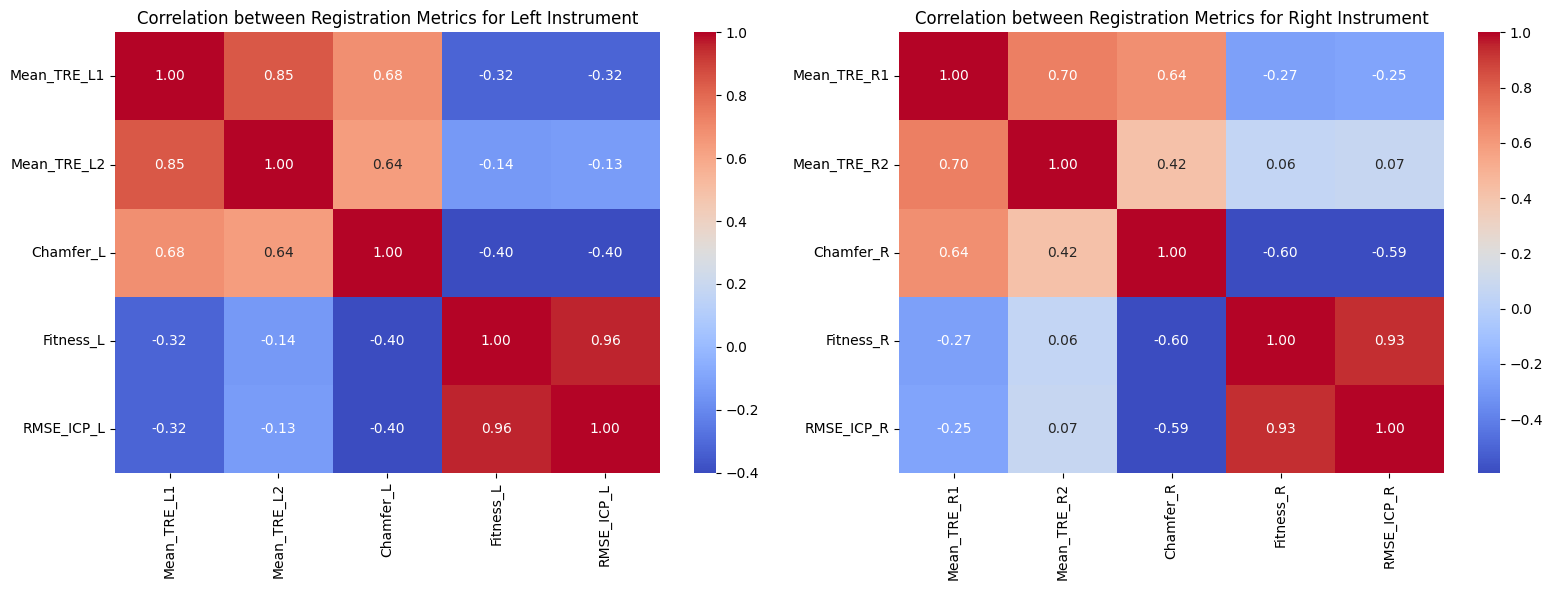

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(correlation_L, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation between Registration Metrics for Left Instrument")
sns.heatmap(correlation_R, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title("Correlation between Registration Metrics for Right Instrument")
plt.tight_layout()
plt.show()

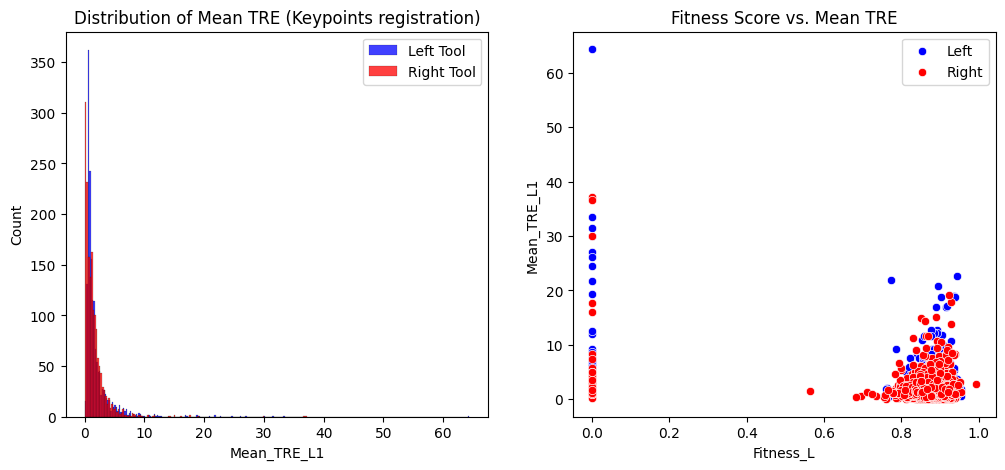

In [9]:
# Visualizing how the TRE behaves across all frames
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Mean_TRE_L1'], color='blue', label='Left Tool')
sns.histplot(df['Mean_TRE_R1'], color='red', label='Right Tool')
plt.title("Distribution of Mean TRE (Keypoints registration)")
plt.legend()

plt.subplot(1, 2, 2)
sns.scatterplot(x='Fitness_L', y='Mean_TRE_L1', data=df, color='blue', label='Left')
sns.scatterplot(x='Fitness_R', y='Mean_TRE_R1', data=df, color='red', label='Right')
plt.title("Fitness Score vs. Mean TRE")
plt.show()



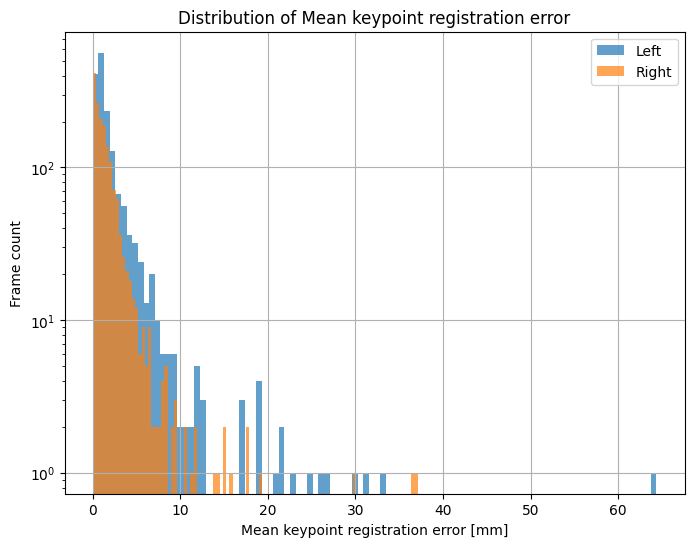

In [10]:
plt.figure(figsize=(8, 6))
df['Mean_TRE_L1'].hist(bins=100, alpha=0.7, label='Left')
df['Mean_TRE_R1'].hist(bins=100, alpha=0.7, label='Right')
plt.xlabel('Mean keypoint registration error [mm]')
plt.ylabel('Frame count')
plt.title('Distribution of Mean keypoint registration error')
plt.yscale('log')
plt.legend()
plt.show()

### ICP Failure cases

In [11]:
failures_left = df[(df['Fitness_L'] < 0.5)]

In [12]:
failures_left.count()

vid_id               55
frame_name           55
Mean_TRE_L1          55
RMSE_TRE_L1          55
Mean_TRE_R1          55
RMSE_TRE_R1          55
Mean_TRE_L2          55
RMSE_TRE_L2          55
Mean_TRE_R2          55
RMSE_TRE_R2          55
Chamfer_L            55
Chamfer_R            55
Chamfer_initial_L    55
Chamfer_initial_R    55
Fitness_L            55
Fitness_R            55
RMSE_ICP_L           55
RMSE_ICP_R           55
dtype: int64

In [13]:
failures_right = df[ (df['Fitness_R'] < 0.5)]

In [14]:
failures_right.count()

vid_id               58
frame_name           58
Mean_TRE_L1          58
RMSE_TRE_L1          58
Mean_TRE_R1          58
RMSE_TRE_R1          58
Mean_TRE_L2          58
RMSE_TRE_L2          58
Mean_TRE_R2          58
RMSE_TRE_R2          58
Chamfer_L            58
Chamfer_R            58
Chamfer_initial_L    58
Chamfer_initial_R    58
Fitness_L            58
Fitness_R            58
RMSE_ICP_L           58
RMSE_ICP_R           58
dtype: int64

In [21]:
# Outlier/Failure Detection based on low fitness
poor_registrations = df[(df['Fitness_L'] < 0.5) | (df['Fitness_R'] < 0.5)]
print(f"\n--- Found {len(poor_registrations)} frames with poor fitness (< 0.5) ---")
print(poor_registrations[['vid_id', 'frame_name', 'Fitness_L', 'Fitness_R', 'Chamfer_L', 'Chamfer_R']])


--- Found 109 frames with poor fitness (< 0.5) ---
      vid_id               frame_name  Fitness_L  Fitness_R  Chamfer_L  \
501        4  vid_000004_frame_000507     0.9015     0.0000   4.086590   
661        4  vid_000004_frame_000987     0.8807     0.0000   2.260626   
666        7  vid_000007_frame_000000     0.8959     0.0000   2.286544   
670        7  vid_000007_frame_000012     0.8719     0.0000   1.639641   
678        7  vid_000007_frame_000036     0.8536     0.0000   1.089142   
...      ...                      ...        ...        ...        ...   
1568      33  vid_000033_frame_000756     0.0000     0.8501  62.288492   
1569      33  vid_000033_frame_000759     0.0000     0.8757  53.079414   
1570      33  vid_000033_frame_000762     0.9182     0.0000   2.323568   
1592      33  vid_000033_frame_000831     0.0000     0.9177  65.407410   
1647      33  vid_000033_frame_000999     0.0000     0.9219  46.246923   

      Chamfer_R  
501   31.526489  
661   46.345415  
666  

In [16]:
print("Statistical Summary:")
print(poor_registrations.drop(['vid_id'], axis=1).describe())

Statistical Summary:
       Mean_TRE_L1  RMSE_TRE_L1  Mean_TRE_R1  RMSE_TRE_R1  Mean_TRE_L2  \
count   109.000000   109.000000   109.000000   109.000000   109.000000   
mean      4.864702     5.236406     4.097107     4.438352     6.859607   
std       8.982816     9.563796     6.090861     6.481007     8.580925   
min       0.253370     0.258377     0.252158     0.271043     0.488732   
25%       0.868013     0.920690     1.466966     1.581591     2.388588   
50%       1.835045     1.964455     2.335014     2.683000     4.770530   
75%       4.653452     5.175189     4.058478     4.501286     7.556696   
max      64.362669    68.303569    37.145723    39.432099    64.362669   

       RMSE_TRE_L2  Mean_TRE_R2  RMSE_TRE_R2    Chamfer_L   Chamfer_R  \
count   109.000000   109.000000   109.000000   109.000000  109.000000   
mean      7.343610     5.514420     6.034788    59.758452   40.826272   
std       9.125253     5.908902     6.546450   184.149415   73.372001   
min       0.503320  